In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emd
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
from sklearn.preprocessing import MinMaxScaler

numpy.ndarray size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject


In [2]:
P8_df = pd.read_csv('/home/baptiste/Desktop/Emploi/Formation/WildCodeSchool/Side_project/Data/P8.csv', 
                 sep = ';', na_values = 'n.a.')
P10_df = pd.read_csv('/home/baptiste/Desktop/Emploi/Formation/WildCodeSchool/Side_project/Data/P10.csv', 
                  sep = ';', na_values = 'n.a.')

In [3]:
P8_df = P8_df.fillna(method = 'ffill')
P10_df = P10_df.fillna(method = 'ffill')

# Functions

In [20]:
def transformer(tple, X):
    '''
    INPUTS
    ------
        - tple : list
            List of tuples of the transformation vector to apply.
        - X : 1Darray
            Array to reshape.
            
    OUTPUT
    ------
        - transform_list : list
            Vector of the X2 positions to apply to X1 data.
    '''
    import operator
    from itertools import groupby
    
    transform_list = []
    for k, g in groupby(tple, operator.itemgetter(0)):
        x = list(g)
        bst_val = []
        for i in x:
            val = i[1]
            pval = X[val]
            bst_val.append(pval)
        
        pos = np.argmin(abs(np.array(bst_val) - np.mean(bst_val)))
        bst_pos = x[pos][1]
        transform_list.append(bst_pos)

    return transform_list

In [21]:
def peaks_to_line(X, peaks):
    new_y = [0]*len(X)
    
    for i in peaks :
        new_y[i] = y[i]
        
    return np.array(new_y)

## Scaling 

On met chaque variable entre 0 et 1 afin d'améliorer les analyses

In [22]:
scaler = MinMaxScaler()

P8_scaled = pd.DataFrame(scaler.fit_transform(P8_df),
                     index = P8_df.index,
                     columns = P8_df.columns)

P10_scaled = pd.DataFrame(scaler.fit_transform(P10_df),
                      index = P10_df.index,
                      columns = P10_df.columns)

In [23]:
P8_scaled = np.array(P8_scaled['msa'])
P10_scaled = np.array(P10_scaled['msa'])

# Clustering

In [24]:
from scipy.signal import savgol_filter, find_peaks

In [25]:
y = savgol_filter(P8_scaled, 2, 0)

In [26]:
peaks1, _ = find_peaks(y, prominence = 0.02)

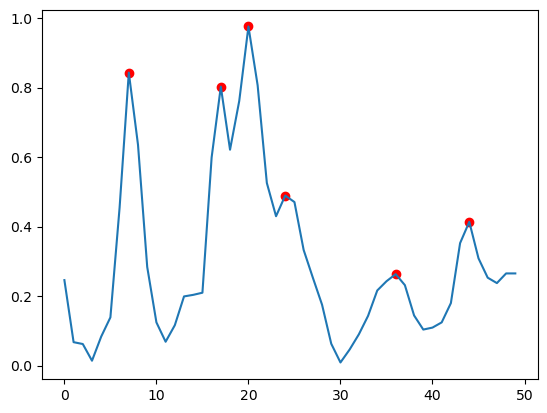

In [27]:
plt.plot(y)
plt.scatter(peaks1, y[peaks1], color = 'red')
plt.show()

In [28]:
y2 = savgol_filter(P10_scaled, 2, 0)

In [29]:
peaks2, _ = find_peaks(y2, prominence = 0.02)

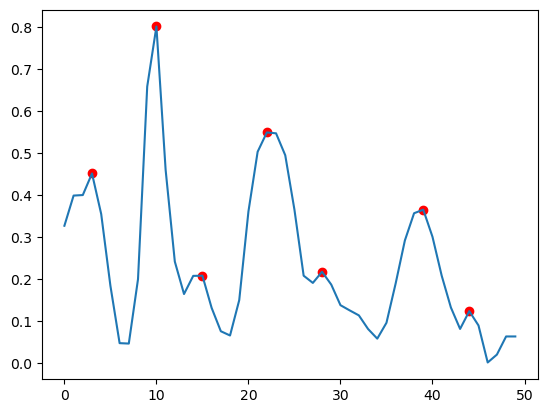

In [30]:
plt.plot(y2)
plt.scatter(peaks2, y2[peaks2], color = 'red')
plt.show()

In [31]:
new_y1 = np.array(peaks_to_line(y, peaks1))
new_y2 = np.array(peaks_to_line(y2, peaks2))

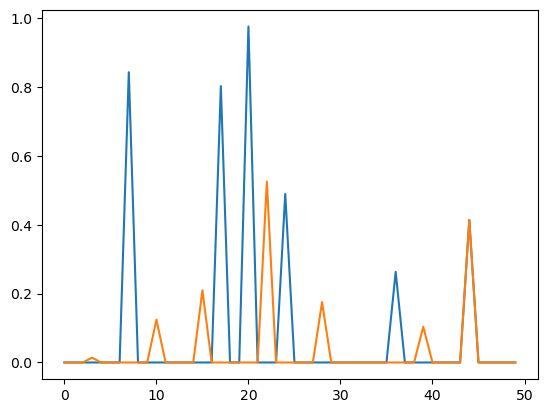

In [32]:
plt.plot(new_y1)
plt.plot(new_y2)
plt.show()

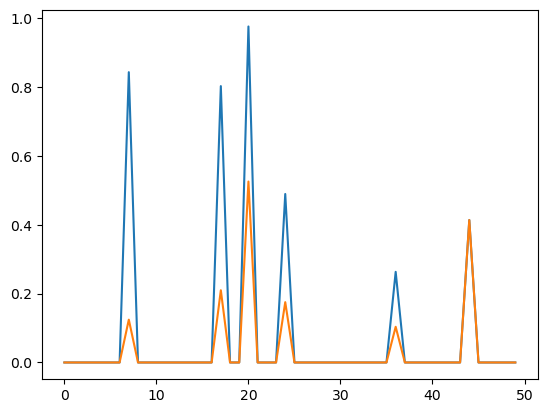

In [35]:
tuple_transform = dtw.warping_path(new_y1, new_y2)
list_transform = transformer(tuple_transform, P10_scaled)

plt.plot(new_y1)
plt.plot(new_y2[list_transform])
plt.show()

In [36]:
X = new_y2[list_transform]

In [153]:
end = [0] * len(X)

count = 0
max_pos = np.where(X != 0)[0]
dic_transform = dict(tuple_transform)

for i in range(len(max_pos)) :
    new = max_pos[i]
    origin = dic_transform[new]
    end[new] = P10_df.loc[origin, 'msa']

    if count == 0 :
        min_pos = np.argmin(P10_df.loc[:origin, 'msa'])
        min_val = np.min(P10_df.loc[:origin, 'msa'])
        real_pos = np.argmin(P8_df.loc[:new, 'msa'])
        end[real_pos] = min_val
        
        lgth1 = 
        
    elif count < len(max_pos) - 1 :
        bfre = dic_transform[max_pos[i-1]]
        min_val = np.min(P10_df.loc[bfre:origin, 'msa'])
        real_pos = np.argmin(P8_df.loc[max_pos[i-1]:new, 'msa']) + max_pos[i-1]
        end[real_pos] = min_val
    else :
        min_val = np.min(P10_df.loc[origin:, 'msa'])
        real_pos = np.argmin(P8_df.loc[new:, 'msa']) + max_pos[i-1]
        end[real_pos] = min_val
        
    count += 1

In [169]:
test = P8_df.loc[:5, 'msa']

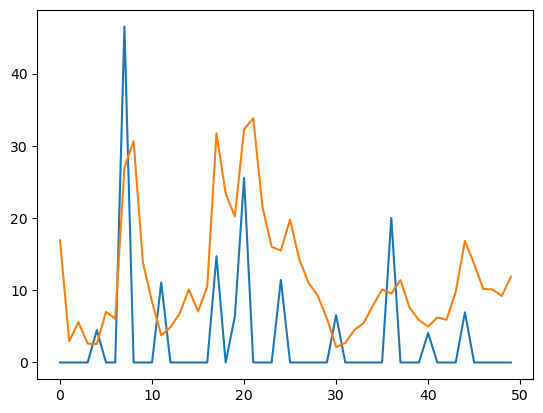

In [155]:
plt.plot(end)
plt.plot(P8_df['msa'])
plt.show()

# EMD method

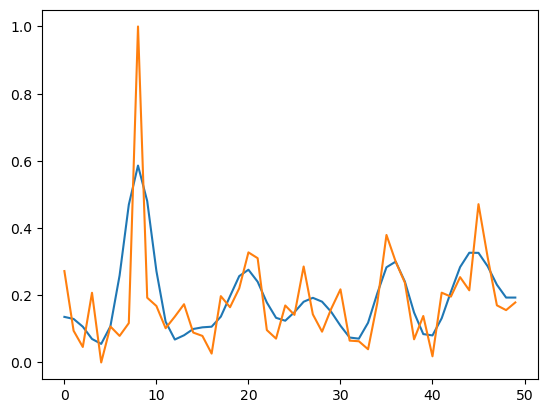

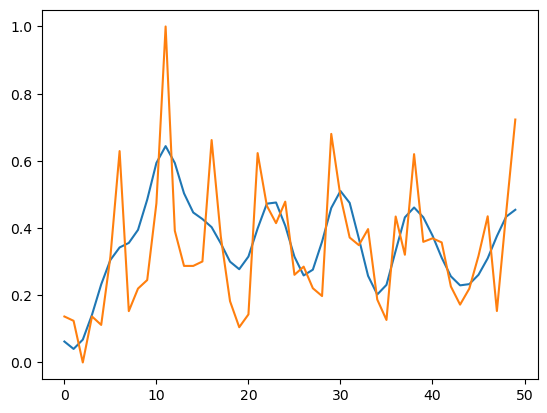

In [22]:
for i in [P8, P10] :
    imf = emd.sift.mask_sift(i, max_imfs = 3)
    plt.plot(i - imf[:, 0])
    plt.plot(i)
    plt.show()

In [74]:
#emd.plotting.plot_imfs(imf)